h = 1, final y = nan
h = 0.01, final y = nan
h = 0.001, final y = 2.9999999999998126
h = 1e-05, final y = 2.999999999999791


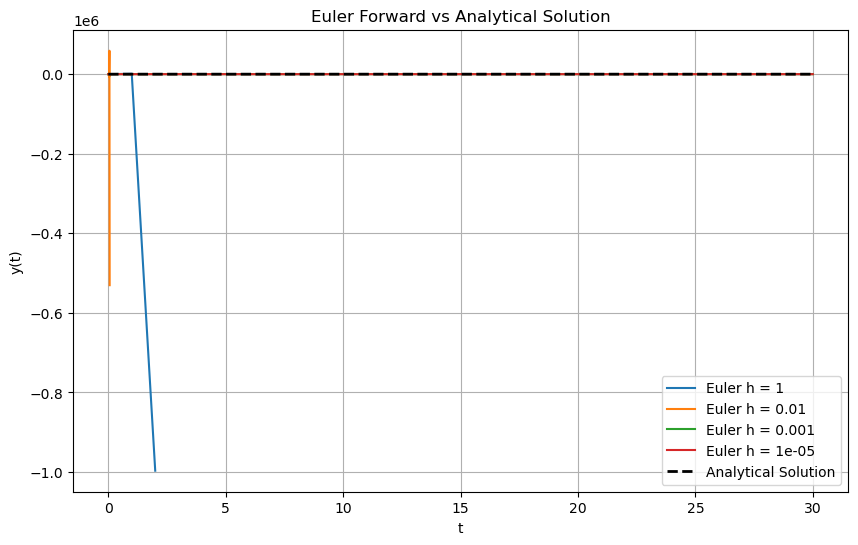

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ChatGPT was used to help organize and check this code.

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

def euler_forward(h, t0, t_end, y0):
    n = int((t_end - t0) / h)
    t = np.linspace(t0, t_end, n + 1)
    y = np.zeros(n + 1)
    y[0] = y0

    for i in range(n):
        y[i + 1] = y[i] + h * f(t[i], y[i])

        # stop if the method blows up
        if abs(y[i + 1]) > 1e6 or np.isnan(y[i + 1]) or np.isinf(y[i + 1]):
            y[i + 1:] = np.nan
            break

    return t, y

t0 = 0
t_end = 30
y0 = 0

# These are the step sizes that will realistically run in Jupyter
h_values = [1, 0.01, 0.001, 0.00001]

plt.figure(figsize=(10, 6))

for h in h_values:
    t_num, y_num = euler_forward(h, t0, t_end, y0)
    plt.plot(t_num, y_num, label=f"Euler h = {h}")
    print(f"h = {h}, final y = {y_num[-1]}")

t_plot = np.linspace(t0, t_end, 2000)
plt.plot(t_plot, y_exact(t_plot), "k--", linewidth=2, label="Analytical Solution")

plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Euler Forward vs Analytical Solution")
plt.legend()
plt.grid(True)
plt.show()
